print("اليوم 1 :بدات")
import pandas as pd
import sys
print("Python:",sys.version.splite()[0])
print("pandas:",pd.__version__)

In [1]:
import pandas as pd; print("Pandas:",pd.__version__) 

Pandas: 2.3.3


In [2]:
import pyodbc
import pandas as pd

conn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=AdventureWorks2019;Trusted_Connection=yes;')

query = "SELECT TOP 5 Name, ListPrice FROM Production.Product ORDER BY ListPrice DESC"
df = pd.read_sql(query, conn)

print("أغلى 5 منتجات من AdventureWorks بـ Python:")
df

أغلى 5 منتجات من AdventureWorks بـ Python:


C:\Users\User\AppData\Local\Temp\ipykernel_8028\2739137922.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Name,ListPrice
0,"Road-150 Red, 62",3578.27
1,"Road-150 Red, 44",3578.27
2,"Road-150 Red, 48",3578.27
3,"Road-150 Red, 52",3578.27
4,"Road-150 Red, 56",3578.27


In [3]:
import pyodbc
import pandas as pd

conn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=AdventureWorks2019;Trusted_Connection=yes;')

sales_df = pd.read_sql("SELECT * FROM Sales.SalesOrderHeader",conn)

print("عدد الصفوف:",len(sales_df))
print("اول 5 اوامر بيع:")
sales_df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_8028\2377403795.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql("SELECT * FROM Sales.SalesOrderHeader",conn)


عدد الصفوف: 31465
اول 5 اوامر بيع:


,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,False,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,None,79B65321-39CA-4115-9CBA-8FE0903E12E6,2011-06-07
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,False,SO43660,PO18850127500,10-4020-000117,...,5618.0,115213Vi29411,NaN,1294.2529,124.2483,38.8276,1457.3288,None,738DC42D-D03B-48A1-9822-F95A67EA7389,2011-06-07
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,False,SO43661,PO18473189620,10-4020-000442,...,1346.0,85274Vi6854,4.0,32726.4786,3153.7696,985.5530,36865.8012,None,D91B9131-18A4-4A11-BC3A-90B6F53E9D74,2011-06-07
3,43662,8,2011-05-31,2011-06-12,2011-06-07,5,False,SO43662,PO18444174044,10-4020-000227,...,10456.0,125295Vi53935,4.0,28832.5289,2775.1646,867.2389,32474.9324,None,4A1ECFC0-CC3A-4740-B028-1C50BB48711C,2011-06-07
4,43663,8,2011-05-31,2011-06-12,2011-06-07,5,False,SO43663,PO18009186470,10-4020-000510,...,4322.0,45303Vi22691,NaN,419.4589,40.2681,12.5838,472.3108,None,9B1E7A40-6AE0-4AD3-811C-A64951857C4B,2011-06-07


In [4]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SalesOrderID            31465 non-null  int64         
 1   RevisionNumber          31465 non-null  int64         
 2   OrderDate               31465 non-null  datetime64[ns]
 3   DueDate                 31465 non-null  datetime64[ns]
 4   ShipDate                31465 non-null  datetime64[ns]
 5   Status                  31465 non-null  int64         
 6   OnlineOrderFlag         31465 non-null  bool          
 7   SalesOrderNumber        31465 non-null  object        
 8   PurchaseOrderNumber     3806 non-null   object        
 9   AccountNumber           31465 non-null  object        
 10  CustomerID              31465 non-null  int64         
 11  SalesPersonID           3806 non-null   float64       
 12  TerritoryID             31465 non-null  int64 

In [5]:
print("=== إحصائيات المبيعات ===")
sales_df[['SubTotal', 'TaxAmt', 'Freight', 'TotalDue']].describe()

print("\n=== إجمالي المبيعات الكلي ===")
total = sales_df['TotalDue'].sum()
print(f"${total:,.2f}")

print("\n=== أكبر 5 أوردرات ===")
sales_df.nlargest(5, 'TotalDue')[['SalesOrderID', 'OrderDate', 'TotalDue']]
 

=== إحصائيات المبيعات ===

=== إجمالي المبيعات الكلي ===
$123,216,786.12

=== أكبر 5 أوردرات ===


,SalesOrderID,OrderDate,TotalDue
7472,51131,2013-05-30,187487.8250
11623,55282,2013-08-30,182018.6272
2957,46616,2012-05-30,170512.6689
3322,46981,2012-06-30,166537.0808
3736,47395,2012-07-31,165028.7482


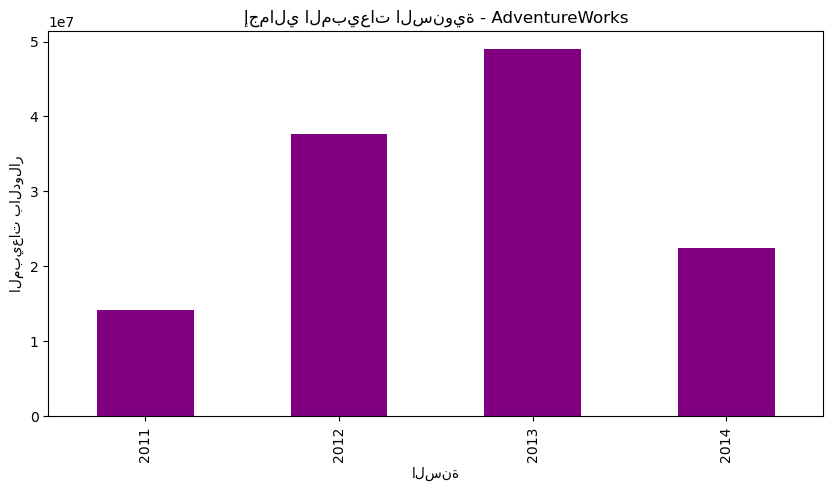

المبيعات بالسنة:


OrderYear
2011    1.415570e+07
2012    3.767570e+07
2013    4.896589e+07
2014    2.241950e+07
Name: TotalDue, dtype: float64

In [6]:
import matplotlib.pyplot as plt

# مبيعات كل سنة
sales_df['OrderYear'] = sales_df['OrderDate'].dt.year
yearly_sales = sales_df.groupby('OrderYear')['TotalDue'].sum()

yearly_sales.plot(kind='bar', figsize=(10,5), color='purple')
plt.title('إجمالي المبيعات السنوية - AdventureWorks')
plt.ylabel('المبيعات بالدولار')
plt.xlabel('السنة')
plt.show()

print("المبيعات بالسنة:")
yearly_sales

In [8]:
customer_df = pd.read_sql("SELECT CustomerID,FirstName,LastName FROM Person.Person JOIN Sales.Customer ON Person.BusinessEntityID = Customer.PersonID",conn)
                                                                                   sales_with_names = sales_df.merge(customer_df,on='CustomerID',how='left')
                                                            top_customers = sales_with_names.groupby(['FirstName','LastName'])['TotalDue'].sum().nlargest(5)
                                                                                                                           print("===اكبر 5 عملاء في الشركة===")
                                                                                                                                                  top_customers                        

IndentationError: unindent does not match any outer indentation level (<string>, line 3)

In [10]:
                 customer_df = pd.read_sql("SELECT CustomerID,PersonID FROM Sales.Customer",conn)
       person_df = pd.read_sql("SELECT BusinessEntityID, FirstName,LastName FROM Person.Person",conn)

customer_names = customer_df.merge(person_df, left_on='PersonID', right_on='BusinessEntityID',how='left')

                            sales_with_names = sales_df.merge(customer_names,on='CustomerID',how='left')

          top_customers = sales_with_names.groupby(['FirstName','LastName'])['TotalDue'].sum().nlargest(5)

                                                                          print("===اكبر 5 عملاء في الشركة===")
                                                                                       print(top_customers)     

IndentationError: unindent does not match any outer indentation level (<string>, line 2)

In [11]:
query = """
SELECT TOP 5 p.FirstName, p.LastName, SUM(s.TotalDue) as TotalSpent
FROM Sales.SalesOrderHeader s
JOIN Sales.Customer c ON s.CustomerID = c.CustomerID
JOIN Person.Person p ON c.PersonID = p.BusinessEntityID
GROUP BY p.FirstName, p.LastName
ORDER BY TotalSpent DESC
"""

top_customers_sql = pd.read_sql(query, conn)
print("=== أكبر 5 عملاء - بـ SQL مباشر ===")
top_customers_sql

C:\Users\User\AppData\Local\Temp\ipykernel_8028\1424987167.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customers_sql = pd.read_sql(query, conn)


=== أكبر 5 عملاء - بـ SQL مباشر ===


,FirstName,LastName,TotalSpent
0,Roger,Harui,989400.9825
1,Andrew,Dixon,961675.8596
2,Reuben,D'sa,954021.9235
3,Robert,Vessa,919801.8188
4,Ryan,Calafato,901346.8560
